In [1]:
import numpy                       
from matplotlib import pyplot      
import time, sys                   

In [58]:
#this makes matplotlib plots appear in the notebook (instead of a separate window)
# %matplotlib inline

In [59]:
nx = 41  # try changing this number from 41 to 81 and Run All
dx = 2 / (nx-1)
nt = 25    #nt is the number of timesteps we want to calculate
dt = .025  #dt is the amount of time each timestep covers (delta t)
c = 1      #assume wavespeed of c = 1

In [60]:
u = numpy.ones(nx)      #numpy function ones()
u[int(.5 / dx):int(1 / dx + 1)] = 2  #setting u = 2 between 0.5 and 1 as per our I.C.s
print(u)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


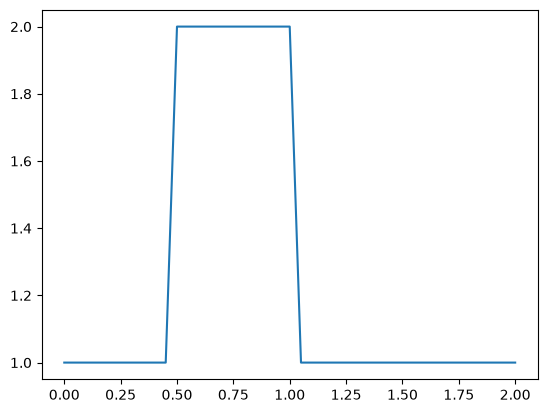

In [61]:
pyplot.plot(numpy.linspace(0, 2, nx), u);

In [62]:
un = numpy.ones(nx)
for _ in range(nt):
    un = u.copy()
    u[1:] = un[1:] - c * dt / dx * (un[1:] - un[:-1])

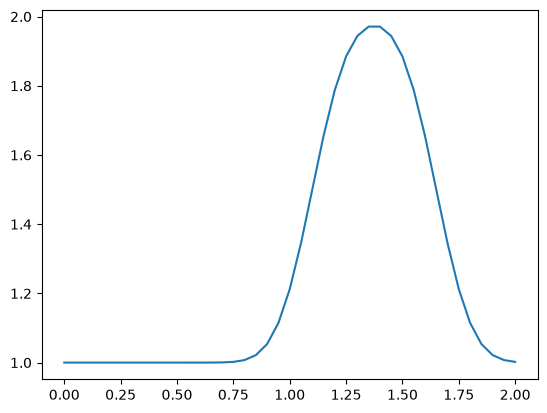

In [63]:
pyplot.plot(numpy.linspace(0, 2, nx), u);

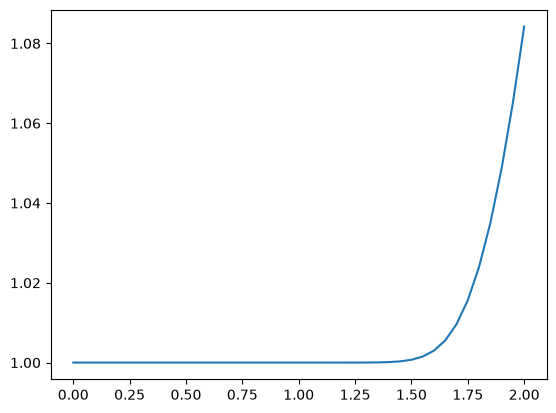

In [64]:
for _ in range(nx):
    un = u.copy()
    u[1:] = un[1:] - u[1:] * dt / dx * (un[1:] - un[:-1])

pyplot.plot(numpy.linspace(0, 2, nx), u)

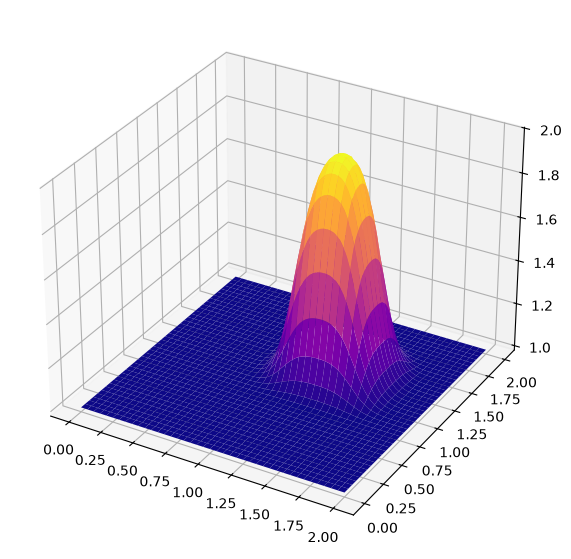

In [79]:
#2D linear convection/advection equation

from mpl_toolkits.mplot3d import Axes3D    ##New Library required for projected 3d plots
from matplotlib import cm

###variable declarations
nx = 81
ny = 81
nt = 100
c = 1
dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma = .2
dt = sigma * dx

x = numpy.linspace(0, 2, nx)
y = numpy.linspace(0, 2, ny)


u = numpy.ones((ny, nx))
u[int(.5 / dy):int(1 / dy + 1), int(.5 / dx):int(1 / dx + 1)] = 2

for n in range(nt + 1): ##loop across number of time steps
    un = u.copy()
    u[1:, 1:] = (un[1:, 1:] - (c * dt / dx * (un[1:, 1:] - un[1:, :-1])) -
                              (c * dt / dy * (un[1:, 1:] - un[:-1, 1:])))
    u[0, :] = 1
    u[-1, :] = 1
    u[:, 0] = 1
    u[:, -1] = 1

fig = pyplot.figure(figsize=(11, 7), dpi=100)
ax = fig.add_subplot(projection="3d")
X, Y = numpy.meshgrid(x, y)
surf2 = ax.plot_surface(X, Y, u[:], cmap=cm.plasma)